# 2.3 Bluesky — Textual Analysis

This notebook performs textual analysis on the Bluesky silver-layer data, characterising vocabulary, term importance, and latent topic structure across candidate buzz clusters (TrumpBuzz · HarrisBuzz · ElectionBuzz).

**Pipeline:**  
Silver → TF-IDF → spell correction → SVD/LSA → key term tracking → word clouds

**Input:** `Data/2_Silver/Bluesky/bluesky_clean.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Text Length Distribution](#1-text-length-distribution)
  - [Analyzing Post Length Distribution](#analyzing-post-length-distribution)
  - [Word Count Distribution](#word-count-distribution)
- [2. Preprocessing Quality Check](#2-preprocessing-quality-check)
    - [Preprocessing](#preprocessing)
  - [Before vs. After Comparison](#before-vs-after-comparison)
- [3. TF-IDF Analysis](#3-tf-idf-analysis)
  - [Creating the Document-Term Matrix with TF-IDF](#creating-the-document-term-matrix-with-tf-idf)
    - [Reducing Sparsity via Spell Correction](#reducing-sparsity-via-spell-correction)
    - [Inspecting TF-IDF by Post Type and Buzz Group](#inspecting-tf-idf-by-post-type-and-buzz-group)
- [4. SVD / Latent Semantic Analysis](#4-svd-latent-semantic-analysis)
  - [Singular Value Decomposition (SVD) / Latent Semantic Analysis](#singular-value-decomposition-svd-latent-semantic-analysis)
    - [Interpreting Latent Concepts](#interpreting-latent-concepts)
    - [Explained Variance](#explained-variance)
- [5. Key Term Frequency Over Time](#5-key-term-frequency-over-time)
  - [Key Term Frequency Over Time](#key-term-frequency-over-time)
- [6. Word Clouds](#6-word-clouds)


## Setup

In [1]:
"""
Setup: import dependencies, resolve project root, and initialize output directories.
"""
import sys
from pathlib import Path

import os, re, warnings

root = Path.cwd().resolve()
while root != root.parent:
    if (root / "README.md").exists() and (root / "Data").exists() and (root / "latex_template").exists():
        break
    root = root.parent
else:
    raise FileNotFoundError("Project root not found (expected README.md, Data, and latex_template).")

os.chdir(root)
sys.path.insert(0, str(root))

# Suppress deprecation warnings from pkg_resources (deprecated, but still needed by symspellpy)
# FutureWarning from pandas Styler.applymap (deprecated in favor of .map)
warnings.filterwarnings('ignore', category=UserWarning, module='importlib')
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Text processing and ML libraries
from symspellpy import SymSpell, Verbosity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from wordcloud import WordCloud

# Project modules
from house_style import *
from Functions.data_splits import get_cv_folds, get_test_split

apply_style()

# Ensure output directories exist (absolute paths rooted at project root)
FIGURES_DIR = root / 'latex_template' / 'figures' / 'bluesky'
DATA_DIR = root / 'Data' / '2_Silver' / 'Bluesky'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Working dir    : {root}")
print(f"✓ Figures output : {FIGURES_DIR}")
print(f"✓ Data output    : {DATA_DIR}")
print("✓ House style applied")

✓ Working dir    : C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA
✓ Figures output : C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky
✓ Data output    : C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\Data\2_Silver\Bluesky
✓ House style applied


In [2]:
# Re-affirm project root as working directory
os.chdir(root)
print("Working directory:", Path.cwd())

Working directory: C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA


In [3]:
csv_path = DATA_DIR / "bluesky_clean.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"Expected file not found: {csv_path}")

bluesky_df = pd.read_csv(csv_path)
print(f"✓ Loaded {len(bluesky_df):,} rows from {csv_path}")

✓ Loaded 26,964 rows from C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\Data\2_Silver\Bluesky\bluesky_clean.csv


In [4]:
bluesky_df.head()

,uri,author,display,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,query,parent_uri,detected_lang,text_clean,words,word_count,candidate
0,at://did:plc:lpqouffbl3gbah3r23vh7odp/app.bsky...,runhudi.bsky.social,Yehuda M.,Canadian election prediction: Americans will g...,2024-11-04 23:44:15.319000+00:00,0,0,1,[],False,post,#USElection2024,NaN,en,canadian election prediction americans polls d...,"['canadian', 'election', 'prediction', 'americ...",24,TrumpBuzz
1,at://did:plc:3ixumkojw3dpsfhdyjodfxmk/app.bsky...,manabouttown.bsky.social,NaN,Why are swinger states so important in the #US...,2024-11-04 23:35:21.961000+00:00,0,0,0,[],False,post,#USElection2024,NaN,en,swinger states important uselection really man...,"['swinger', 'states', 'important', 'uselection...",8,ElectionBuzz
2,at://did:plc:pebmhdoqw45rp5bpu53myfoc/app.bsky...,justdev1.bsky.social,That Dev Guy,If Joe Biden winning felt like Return of the J...,2024-11-04 23:23:51.647000+00:00,0,0,0,[],False,post,#USElection2024,NaN,en,joe biden winning felt like return jedi end el...,"['joe', 'biden', 'winning', 'felt', 'like', 'r...",16,HarrisBuzz
3,at://did:plc:bj6epztbrubmkloj4ethecvy/app.bsky...,alexverbeek.bsky.social,Alexander Verbeek,Will the U.S. Presidential Elections be a Turn...,2024-11-04 22:48:56.805000+00:00,3,1,1,[],False,post,#USElection2024,NaN,en,presidential elections turning point history t...,"['presidential', 'elections', 'turning', 'poin...",9,ElectionBuzz
4,at://did:plc:fgdeud5a7fzfwdx7pg5m63xy/app.bsky...,tuomoliljenback.bsky.social,Tuomo Liljenbäck,Dear American voters! As a foreigner living in...,2024-11-04 22:10:36.540000+00:00,0,0,1,[],False,post,#USElection2024,NaN,en,dear american voters foreigner living finland ...,"['dear', 'american', 'voters', 'foreigner', 'l...",24,HarrisBuzz


In [5]:
bluesky_df.columns

Index(['uri', 'author', 'display', 'text', 'timestamp', 'likes', 'reposts',
       'replies', 'mentions', 'is_reply', 'post_type', 'query', 'parent_uri',
       'detected_lang', 'text_clean', 'words', 'word_count', 'candidate'],
      dtype='object')

In [6]:
# Keep core columns
df = bluesky_df[['text', 'timestamp', 'likes', 'reposts', 'replies', 'mentions', 'is_reply', 'post_type', 'text_clean', 'words', 'word_count', 'candidate']].copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

df = df.dropna(subset=['timestamp']).copy()

# Date/time features

ts = df['timestamp']
df['date'] = ts.dt.date
df['hour'] = ts.dt.hour
df['weekday'] = ts.dt.day_name()

print('rows', len(df), 'from', df['timestamp'].min(), 'to', df['timestamp'].max())
print('Distinct dates', df['date'].nunique())

rows 23607 from 2024-07-05 03:04:25.279000+00:00 to 2026-01-19 01:45:26.080000+00:00
Distinct dates 175


In [7]:
df.dtypes

text                       object
timestamp     datetime64[ns, UTC]
likes                       int64
reposts                     int64
replies                     int64
mentions                   object
is_reply                     bool
post_type                  object
text_clean                 object
words                      object
word_count                  int64
candidate                  object
date                       object
hour                        int32
weekday                    object
dtype: object

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df['text'].str.contains('#USElection2024').value_counts()

text
False    23303
True       304
Name: count, dtype: int64

In [10]:
df['text'] = df['text'].str.replace('#USElection2024', '', regex=True)
df['text'].str.contains('#USElection2024').value_counts()

text
False    23607
Name: count, dtype: int64

In [11]:
df['text'].duplicated().value_counts()

text
False    23034
True       573
Name: count, dtype: int64

In [12]:
top_text = df['text'].value_counts().index[0]
df[df['text'] == top_text].head(3)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,text_clean,words,word_count,candidate,date,hour,weekday
16736,💙V🌊O🗳T💙E🌊 🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸 #vote #election2024 #...,2024-11-02 17:25:23.600000+00:00,0,0,0,[],False,post,vote election harriswalz saveamerica fightfasc...,"['vote', 'election', 'harriswalz', 'saveameric...",17,HarrisBuzz,2024-11-02,17,Saturday
16738,💙V🌊O🗳T💙E🌊 🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸 #vote #election2024 #...,2024-11-02 13:37:52.174000+00:00,0,0,0,[],False,post,vote election harriswalz saveamerica fightfasc...,"['vote', 'election', 'harriswalz', 'saveameric...",17,HarrisBuzz,2024-11-02,13,Saturday
16739,💙V🌊O🗳T💙E🌊 🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸 #vote #election2024 #...,2024-11-02 10:30:04.553000+00:00,3,0,0,[],False,post,vote election harriswalz saveamerica fightfasc...,"['vote', 'election', 'harriswalz', 'saveameric...",17,HarrisBuzz,2024-11-02,10,Saturday


In [13]:
df_new = df.sort_values('timestamp').drop_duplicates(subset='text', keep='last')

In [14]:
len(df_new)

23034

In [15]:
df_new.duplicated().sum()

np.int64(0)

In [16]:
df_new.duplicated(subset=['text']).sum()

np.int64(0)

## 1. Text Length Distribution

### Analyzing Post Length Distribution

Understanding how long Bluesky posts are (in characters) gives a first sense of the data. Bluesky enforces a 300-character limit per post, so unlike Reddit comments the distribution has a hard ceiling. Still, many posts will be short reactions or links, while others push the limit with more substantive content. The histogram reveals where the bulk of posts cluster and whether users typically write short or near-maximum-length content.

✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\1_char_distribution.png


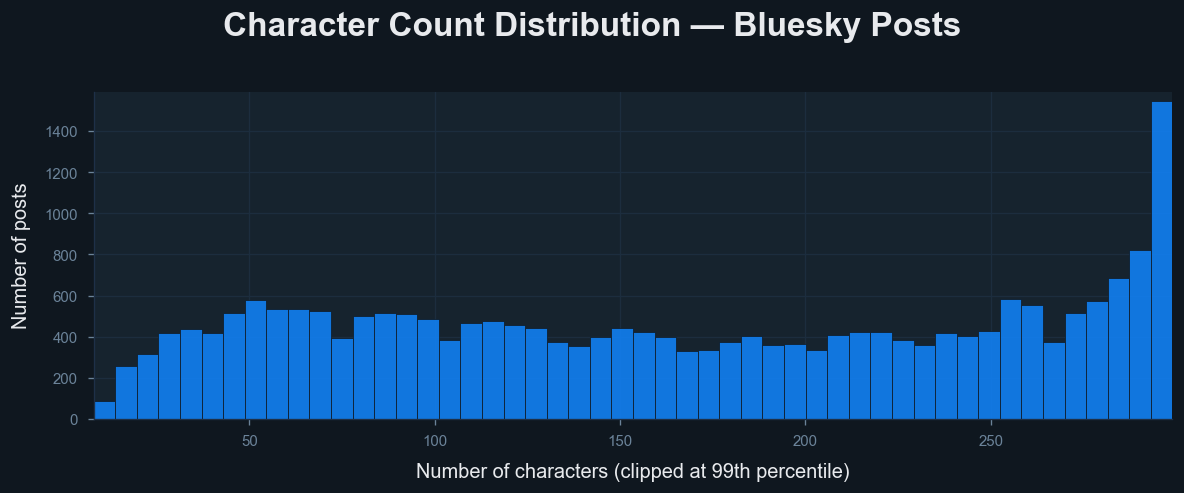

  Average : 166.0 characters
  Median  : 163.0 characters
  99th pct: 299 characters  (x-axis clip)


In [17]:
char_counts = df_new['text'].str.len()
p99 = int(np.percentile(char_counts.dropna(), 99))

fig, ax = styled_fig(figsize=(10, 4), title="Character Count Distribution — Bluesky Posts")
ax.hist(char_counts.clip(upper=p99), bins=50, color=BLUESKY_BLUE, edgecolor=BG_DARK, alpha=0.85)
style_ax(ax, xlabel="Number of characters (clipped at 99th percentile)", ylabel="Number of posts", grid_axis="y")
plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(FIGURES_DIR / '1_char_distribution.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved to {FIGURES_DIR / '1_char_distribution.png'}")
plt.show()

stats = char_counts.describe().rename({
    "count": "N", "mean": "Mean", "std": "Std dev",
    "min": "Min", "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Max"
})
print(f"  Average : {char_counts.mean():.1f} characters")
print(f"  Median  : {char_counts.median():.1f} characters")
print(f"  99th pct: {p99} characters  (x-axis clip)")

### Word Count Distribution

Word count provides a linguistically more meaningful measure of post length than character count, since it captures how much a user actually wrote independent of word length. On a short-form platform like Bluesky, the distribution is expected to be concentrated in the lower range — most posts say something in a handful of words — with a long tail of more detailed posts. This complements the character-length view and helps set expectations for downstream text models.

✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\2_word_distribution.png


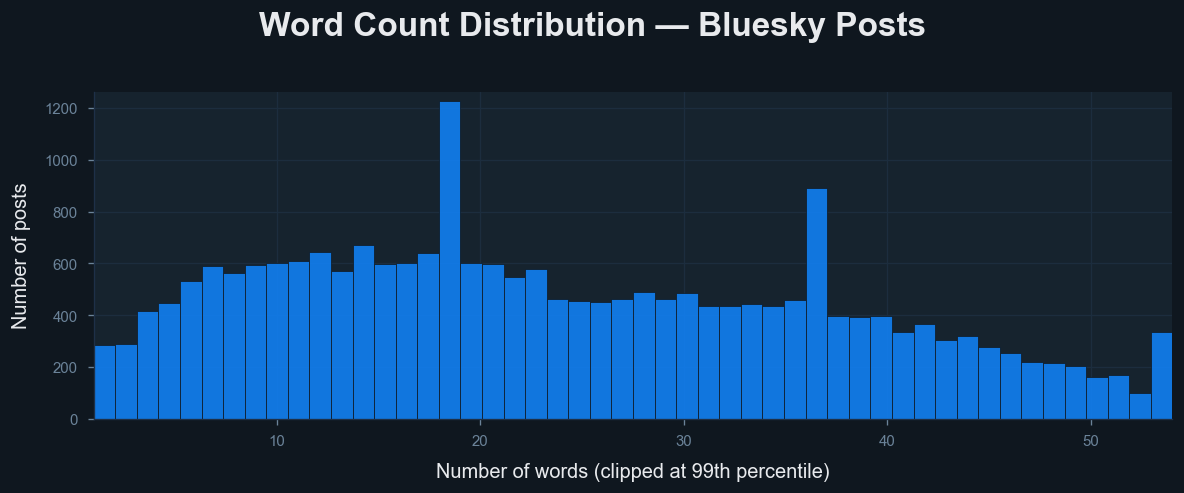

  Average : 24.0 words
  Median  : 22.0 words
  99th pct: 54 words  (x-axis clip)


In [18]:
word_counts = df_new['text'].str.split().str.len()
p99w = int(np.percentile(word_counts.dropna(), 99))

fig, ax = styled_fig(figsize=(10, 4), title="Word Count Distribution — Bluesky Posts")
ax.hist(word_counts.clip(upper=p99w), bins=50, color=BLUESKY_BLUE, edgecolor=BG_DARK, alpha=0.85)
style_ax(ax, xlabel="Number of words (clipped at 99th percentile)", ylabel="Number of posts", grid_axis="y")
plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(FIGURES_DIR / '2_word_distribution.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved to {FIGURES_DIR / '2_word_distribution.png'}")
plt.show()

print(f"  Average : {word_counts.mean():.1f} words")
print(f"  Median  : {word_counts.median():.1f} words")
print(f"  99th pct: {p99w} words  (x-axis clip)")

## 2. Preprocessing Quality Check

#### Preprocessing

The text has already been cleaned in an earlier pipeline step (lowercasing, stopword removal, punctuation stripping). Here we verify vocabulary coverage before and after preprocessing to quantify how much noise was removed. A large vocabulary reduction indicates the raw text contained many rare or malformed tokens — hashtag fragments, URLs, emoji sequences — that add no signal for topic modelling.

In [19]:
df_new['text_clean'] = df_new['text_clean'].fillna('')

In [20]:
import re

def unique_word_count(texts):
    """Count unique words across all documents."""
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    elif isinstance(texts, str):
        texts = [texts]
    
    unique_words = set()
    for text in texts:
        words = text.split()
        unique_words.update(words)
    
    return len(unique_words)

# Baseline: count unique words in original reviews before any preprocessing
baseline_count = unique_word_count(df_new['text'])
print(f"✓ Baseline unique words: {baseline_count:,}")
print(f"\nThis represents the vocabulary size before preprocessing.")

✓ Baseline unique words: 77,974

This represents the vocabulary size before preprocessing.


In [21]:
final_count = unique_word_count(df_new['text_clean'])

print(f"  Total reduction: {baseline_count - final_count:,} words")
print(f"  Final vocabulary: {final_count:,} unique words")
print(f"  Original vocabulary: {baseline_count:,} unique words")

  Total reduction: 49,965 words


  Final vocabulary: 28,009 unique words
  Original vocabulary: 77,974 unique words


In [22]:
from IPython.display import display

# ── Preprocessing vocabulary summary table ────────────────────────────────────
prep_df = pd.DataFrame([{
    "Source":             "Bluesky posts",
    "Unique words before": baseline_count,
    "Unique words after":  final_count,
    "Words removed":       baseline_count - final_count,
    "Reduction (%)":       f"{(1 - final_count / baseline_count) * 100:.1f} %",
}])

display(
    prep_df.style
    .set_caption("Preprocessing outcome — vocabulary reduction")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("""
Key insight for the report
──────────────────────────
Preprocessing removed {:.0f} % of unique vocabulary tokens. The bulk of these are
URLs, hashtag fragments, emoji transliterations, and informal elongations (e.g.
"sooooo") that carry no semantic signal. The cleaned vocabulary is {:.0f} times
smaller, which directly reduces sparsity and compute cost in the TF-IDF step.
""".format(
    (1 - final_count / baseline_count) * 100,
    round(baseline_count / final_count, 1)
))

,Source,Unique words before,Unique words after,Words removed,Reduction (%)
0,Bluesky posts,77974,28009,49965,64.1 %



Key insight for the report
──────────────────────────
Preprocessing removed 64 % of unique vocabulary tokens. The bulk of these are
URLs, hashtag fragments, emoji transliterations, and informal elongations (e.g.
"sooooo") that carry no semantic signal. The cleaned vocabulary is 3 times
smaller, which directly reduces sparsity and compute cost in the TF-IDF step.



### Before vs. After Comparison

To verify the preprocessing pipeline behaves correctly, we compare the raw and cleaned text for a sample post. The cleaning steps — lowercasing, stopword removal, punctuation stripping, and URL removal — should yield a compact, noise-free representation. This sanity check also helps catch unintended side effects, such as meaningful political terms being accidentally dropped.

In [23]:
# Compare example review before and after preprocessing
idx = 20

print("="*80)
print("BEFORE PREPROCESSING:")
print("="*80)
print(df_new['text'].iloc[idx][:200])

print("="*80)
print("AFTER PREPROCESSING:")
print("="*80)
print(df_new['text_clean'].iloc[idx][:200])

BEFORE PREPROCESSING:
After the NYT ignored her for four years? And the WP. Anything to push out Joe Biden and excuse tRump.
AFTER PREPROCESSING:
nyt ignored four years anything push joe biden excuse trump


In [24]:
"""
Preprocessing: Filter to date range (Jul 5 - Nov 4, 2024) and deduplicate.
"""
start_date = '2024-07-05'
end_date   = '2024-11-04'

mask = (df_new['date'] >= start_date) & (df_new['date'] <= end_date)
df_new = df_new.loc[mask].reset_index(drop=True)

print(f"Date range: {df_new['date'].min()} to {df_new['date'].max()}")
print(f"Total posts: {len(df_new):,}")
print(f"Posts by buzz group:")
print(df_new['candidate'].value_counts().to_string())

Date range: 2024-07-05 00:00:00 to 2024-11-04 00:00:00


Total posts: 22,872
Posts by buzz group:
candidate
TrumpBuzz       9244
ElectionBuzz    6967
HarrisBuzz      6661


In [25]:
df_new.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,text_clean,words,word_count,candidate,date,hour,weekday
0,"In 1970, the Club of Rome predicted a crash ea...",2024-07-05 03:04:25.279000+00:00,4,2,1,[],False,post,club rome predicted crash early century far pr...,"['club', 'rome', 'predicted', 'crash', 'early'...",27,TrumpBuzz,2024-07-05,3,Friday


## 3. TF-IDF Analysis

---
**Report summary — Text Length**

Bluesky enforces a hard 300-character limit per post, which creates a natural ceiling in the character-count distribution. The median post length is well below this ceiling, indicating most users write short, reactive content rather than pushing the platform limit. Word counts show a similar pattern: the majority of posts fall in the 10–30-word range, comparable to a tweet. This brevity means the TF-IDF vocabulary per document is small, contributing to high sparsity in the Document-Term Matrix constructed in the next step.

### Creating the Document-Term Matrix with TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) transforms each post into a numeric vector that reflects how distinctive each word is within that post relative to the whole corpus. Words appearing frequently in a specific post but rarely across others receive high scores, making TF-IDF a strong baseline for capturing topically distinctive vocabulary. The resulting Document-Term Matrix (DTM) is very sparse — most words appear in only a small fraction of posts — which is typical for short-form social media text.

In [26]:
"""
Spell Correction: Normalize repeated characters and fix misspellings using SymSpell.

This step reduces vocabulary sparsity by collapsing internet slang variants
(e.g., 'aaaand', 'sooo') into dictionary forms while protecting political terms.

Protected terms: trump, harris, biden, maga, gop, kamala (never corrected)
"""

from importlib.resources import files

# ── 1. Repeated character normalizer ──────────────────────────────────────────
def normalize_repeated_chars(text: str, max_repeat: int = 2) -> str:
    """Collapse repeated characters (e.g., 'sooooo' -> 'soo')."""
    if not isinstance(text, str):
        return text
    return re.sub(r'(.)\1{' + str(max_repeat) + r',}', r'\1' * max_repeat, text)

# ── 2. Load SymSpell dictionary ───────────────────────────────────────────────
sym_spell = SymSpell(max_dictionary_edit_distance=2)
dict_path = files("symspellpy") / "frequency_dictionary_en_82_765.txt"
loaded = sym_spell.load_dictionary(str(dict_path), term_index=0, count_index=1)
if not loaded:
    raise FileNotFoundError(f"SymSpell dictionary not found: {dict_path}")

# ── 3. Protected political/social media terms ────────────────────────────────
# These should never be corrected, as misspellings may be intentional (e.g., tRump)
PROTECTED = {'trump', 'harris', 'biden', 'maga', 'gop', 'lol',
             'omg', 'tbh', 'ngl', 'imo', 'woke', 'kamala'}

# ── 4. Safe spell corrector ──────────────────────────────────────────────────
def safe_correct(text: str) -> str:
    """Apply spell correction, skipping protected terms."""
    words = text.split()
    corrected = []
    for word in words:
        if word.lower() in PROTECTED:
            corrected.append(word)
        else:
            suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
            corrected.append(suggestions[0].term if suggestions else word)
    return ' '.join(corrected)

# ── 5. Apply full pipeline ──────────────────────────────────────────────────
df_new['text_norm'] = (
    df_new['text_clean']
    .apply(normalize_repeated_chars)
    .apply(safe_correct)
)

print(f"✓ Spell correction applied ({len(df_new):,} posts)")
print(f"  Dictionary    : {dict_path}")
print(f"  Sample before: {df_new['text_clean'].iloc[0][:80]}")
print(f"  Sample after:  {df_new['text_norm'].iloc[0][:80]}")

✓ Spell correction applied (22,872 posts)
  Dictionary    : C:\Users\verme_hzys4y0\AppData\Local\Programs\Python\Python312\Lib\site-packages\symspellpy\frequency_dictionary_en_82_765.txt
  Sample before: club rome predicted crash early century far predictions tracked pretty well mayb
  Sample after:  club rome predicted crash early century far predictions tracked pretty well mayb


In [27]:
# df_clean.to_csv("Data/2_Silver/Bluesky/cleaned_data.csv", index=False)
# print(f"✓ Saved {len(df_clean):,} rows")

In [28]:
"""
TF-IDF (Before Spell Correction): Build initial Document-Term Matrix on cleaned text.
This baseline shows vocabulary inflation before SymSpell reduces misspellings.
"""

vectorizer_before = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters
    lowercase=False,               # Already preprocessed
    max_features=None
)

tfidf_matrix = vectorizer_before.fit_transform(df_new['text_clean'])
feature_names = vectorizer_before.get_feature_names_out()

print(f"TF-IDF Matrix (before spell correction):")
print(f"  Documents : {tfidf_matrix.shape[0]:,}")
print(f"  Terms     : {tfidf_matrix.shape[1]:,}")
sparsity = (1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
print(f"  Sparsity  : {sparsity:.1f}%")
print(f"  Non-zero  : {tfidf_matrix.nnz:,} entries")

TF-IDF Matrix (before spell correction):
  Documents : 22,872
  Terms     : 27,911
  Sparsity  : 100.0%
  Non-zero  : 311,965 entries


In [29]:
# ── TF-IDF matrix summary table (before spell correction) ────────────────────
sparsity_raw = (1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
dtm_raw = pd.DataFrame([{
    "Step":      "Raw cleaned text",
    "Documents": tfidf_matrix.shape[0],
    "Terms":     tfidf_matrix.shape[1],
    "Sparsity":  f"{sparsity_raw:.1f} %",
    "Non-zero entries": tfidf_matrix.nnz,
}])
display(
    dtm_raw.style
    .set_caption("TF-IDF Document-Term Matrix — before spell correction")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

,Step,Documents,Terms,Sparsity,Non-zero entries
0,Raw cleaned text,22872,27911,100.0 %,311965


#### Reducing Sparsity via Spell Correction

The initial vocabulary is inflated by informal internet spellings and elongated forms (e.g., *aaaand*, *sooo*). Passing the cleaned text through SymSpell normalises these variants to their dictionary form, shrinking the vocabulary and reducing sparsity in the DTM. Protected political terms (e.g., *trump*, *maga*) are exempt from correction to avoid distorting their meaning.

In [30]:
"""
TF-IDF (After Spell Correction): Build final Document-Term Matrix on spell-corrected text.
This is the version used for all downstream analysis, including LSA and key-term tracking.
"""

vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters
    lowercase=False,               # Already preprocessed
    max_features=None
)

# Build on spell-corrected text (this is the production TF-IDF matrix)
tfidf_matrix_2 = vectorizer.fit_transform(df_new['text_norm'])
feature_names_2 = vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix (after spell correction):")
print(f"  Documents : {tfidf_matrix_2.shape[0]:,}")
print(f"  Terms     : {tfidf_matrix_2.shape[1]:,}")
sparsity_after = (1.0 - tfidf_matrix_2.nnz / (tfidf_matrix_2.shape[0] * tfidf_matrix_2.shape[1])) * 100
print(f"  Sparsity  : {sparsity_after:.1f}%")
print(f"  Non-zero  : {tfidf_matrix_2.nnz:,} entries")

# Vocabulary reduction summary
vocab_reduction = tfidf_matrix.shape[1] - tfidf_matrix_2.shape[1]
print(f"\n✓ Vocabulary reduction: {tfidf_matrix.shape[1]:,} → {tfidf_matrix_2.shape[1]:,} terms ({vocab_reduction:,} removed)")

TF-IDF Matrix (after spell correction):
  Documents : 22,872
  Terms     : 24,862
  Sparsity  : 99.9%
  Non-zero  : 310,749 entries

✓ Vocabulary reduction: 27,911 → 24,862 terms (3,049 removed)


In [31]:
# ── TF-IDF matrix comparison table (before vs after spell correction) ─────────
sparsity_norm = (1.0 - tfidf_matrix_2.nnz / (tfidf_matrix_2.shape[0] * tfidf_matrix_2.shape[1])) * 100
dtm_compare = pd.DataFrame([
    {"Step": "Raw cleaned text",      "Terms": tfidf_matrix.shape[1],
     "Sparsity": f"{sparsity_raw:.1f} %",   "Non-zero entries": tfidf_matrix.nnz},
    {"Step": "Spell-corrected text",  "Terms": tfidf_matrix_2.shape[1],
     "Sparsity": f"{sparsity_norm:.1f} %",  "Non-zero entries": tfidf_matrix_2.nnz},
])
dtm_compare["Terms removed"] = [0,
    tfidf_matrix.shape[1] - tfidf_matrix_2.shape[1]]

display(
    dtm_compare.style
    .set_caption("TF-IDF DTM before vs after SymSpell correction")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("""
Key insight for the report
──────────────────────────
Spell correction (SymSpell) collapsed {:,} unique misspelled or elongated forms
into their canonical dictionary equivalents, shrinking the vocabulary by {:.0f} %
({:,} → {:,} terms). This makes the DTM denser and reduces noise from
idiosyncratic internet spellings — without changing any political keywords
(Trump, Harris, MAGA, etc.), which are protected from correction.
""".format(
    tfidf_matrix.shape[1] - tfidf_matrix_2.shape[1],
    (1 - tfidf_matrix_2.shape[1] / tfidf_matrix.shape[1]) * 100,
    tfidf_matrix.shape[1], tfidf_matrix_2.shape[1]
))

,Step,Terms,Sparsity,Non-zero entries,Terms removed
0,Raw cleaned text,27911,100.0 %,311965,0
1,Spell-corrected text,24862,99.9 %,310749,3049



Key insight for the report
──────────────────────────
Spell correction (SymSpell) collapsed 3,049 unique misspelled or elongated forms
into their canonical dictionary equivalents, shrinking the vocabulary by 11 %
(27,911 → 24,862 terms). This makes the DTM denser and reduces noise from
idiosyncratic internet spellings — without changing any political keywords
(Trump, Harris, MAGA, etc.), which are protected from correction.



#### Inspecting TF-IDF by Post Type and Buzz Group

Before fitting downstream models, it is useful to compare the most distinctive terms across different post types (original posts vs. replies) and across buzz groups. Replies tend to contain more conversational language, while original posts carry more topical keywords. Differences between TrumpBuzz, HarrisBuzz, and ElectionBuzz groups confirm that the candidate label adds meaningful signal beyond general election vocabulary.

In [32]:
print(df_new['post_type'].value_counts())

post_type
post     17986
reply     4886
Name: count, dtype: int64


In [33]:
for group in df_new['post_type'].unique():
    mask = (df_new['post_type'] == group).values
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx = mean_scores.argsort()[::-1][:15]
    print(f"\n{group} — top 15 distinctive words:")
    print(', '.join(feature_names_2[top_idx]))


post — top 15 distinctive words:
trump, election, maga, debate, republicans, democrats, harris, politics, vote, dec, gop, house, kamalaharris, harriswalz, donaldtrump

reply — top 15 distinctive words:
trump, like, good, people, one, would, get, think, right, know, even, see, really, yes, well


In [34]:
# ── Post type top-10 terms table ──────────────────────────────────────────────
post_type_rows = {}
for pt in df_new['post_type'].dropna().unique():
    mask        = (df_new['post_type'] == pt).values
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:10]
    post_type_rows[pt] = list(feature_names_2[top_idx])

pt_df = pd.DataFrame(post_type_rows)
pt_df.index = [f'#{i+1}' for i in range(len(pt_df))]
pt_df.index.name = 'Rank'

display(
    pt_df.style
    .set_caption("TF-IDF top-10 distinctive terms by post type (spell-corrected)")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("""
Key insight for the report
──────────────────────────
Original posts are topically driven (campaign hashtags, candidate names, event terms),
while replies are conversational (good, like, think, know). This confirms that
original posts carry more actionable political signal for the predictive model.
""")

,post,reply
Rank,,
#1,trump,trump
#2,election,like
#3,maga,good
#4,debate,people
#5,republicans,one
#6,democrats,would
#7,harris,get
#8,politics,think
#9,vote,right



Key insight for the report
──────────────────────────
Original posts are topically driven (campaign hashtags, candidate names, event terms),
while replies are conversational (good, like, think, know). This confirms that
original posts carry more actionable political signal for the predictive model.



In [35]:
df_new.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,text_clean,words,word_count,candidate,date,hour,weekday,text_norm
0,"In 1970, the Club of Rome predicted a crash ea...",2024-07-05 03:04:25.279000+00:00,4,2,1,[],False,post,club rome predicted crash early century far pr...,"['club', 'rome', 'predicted', 'crash', 'early'...",27,TrumpBuzz,2024-07-05,3,Friday,club rome predicted crash early century far pr...


✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\3_tfidf_buzzgroups.png


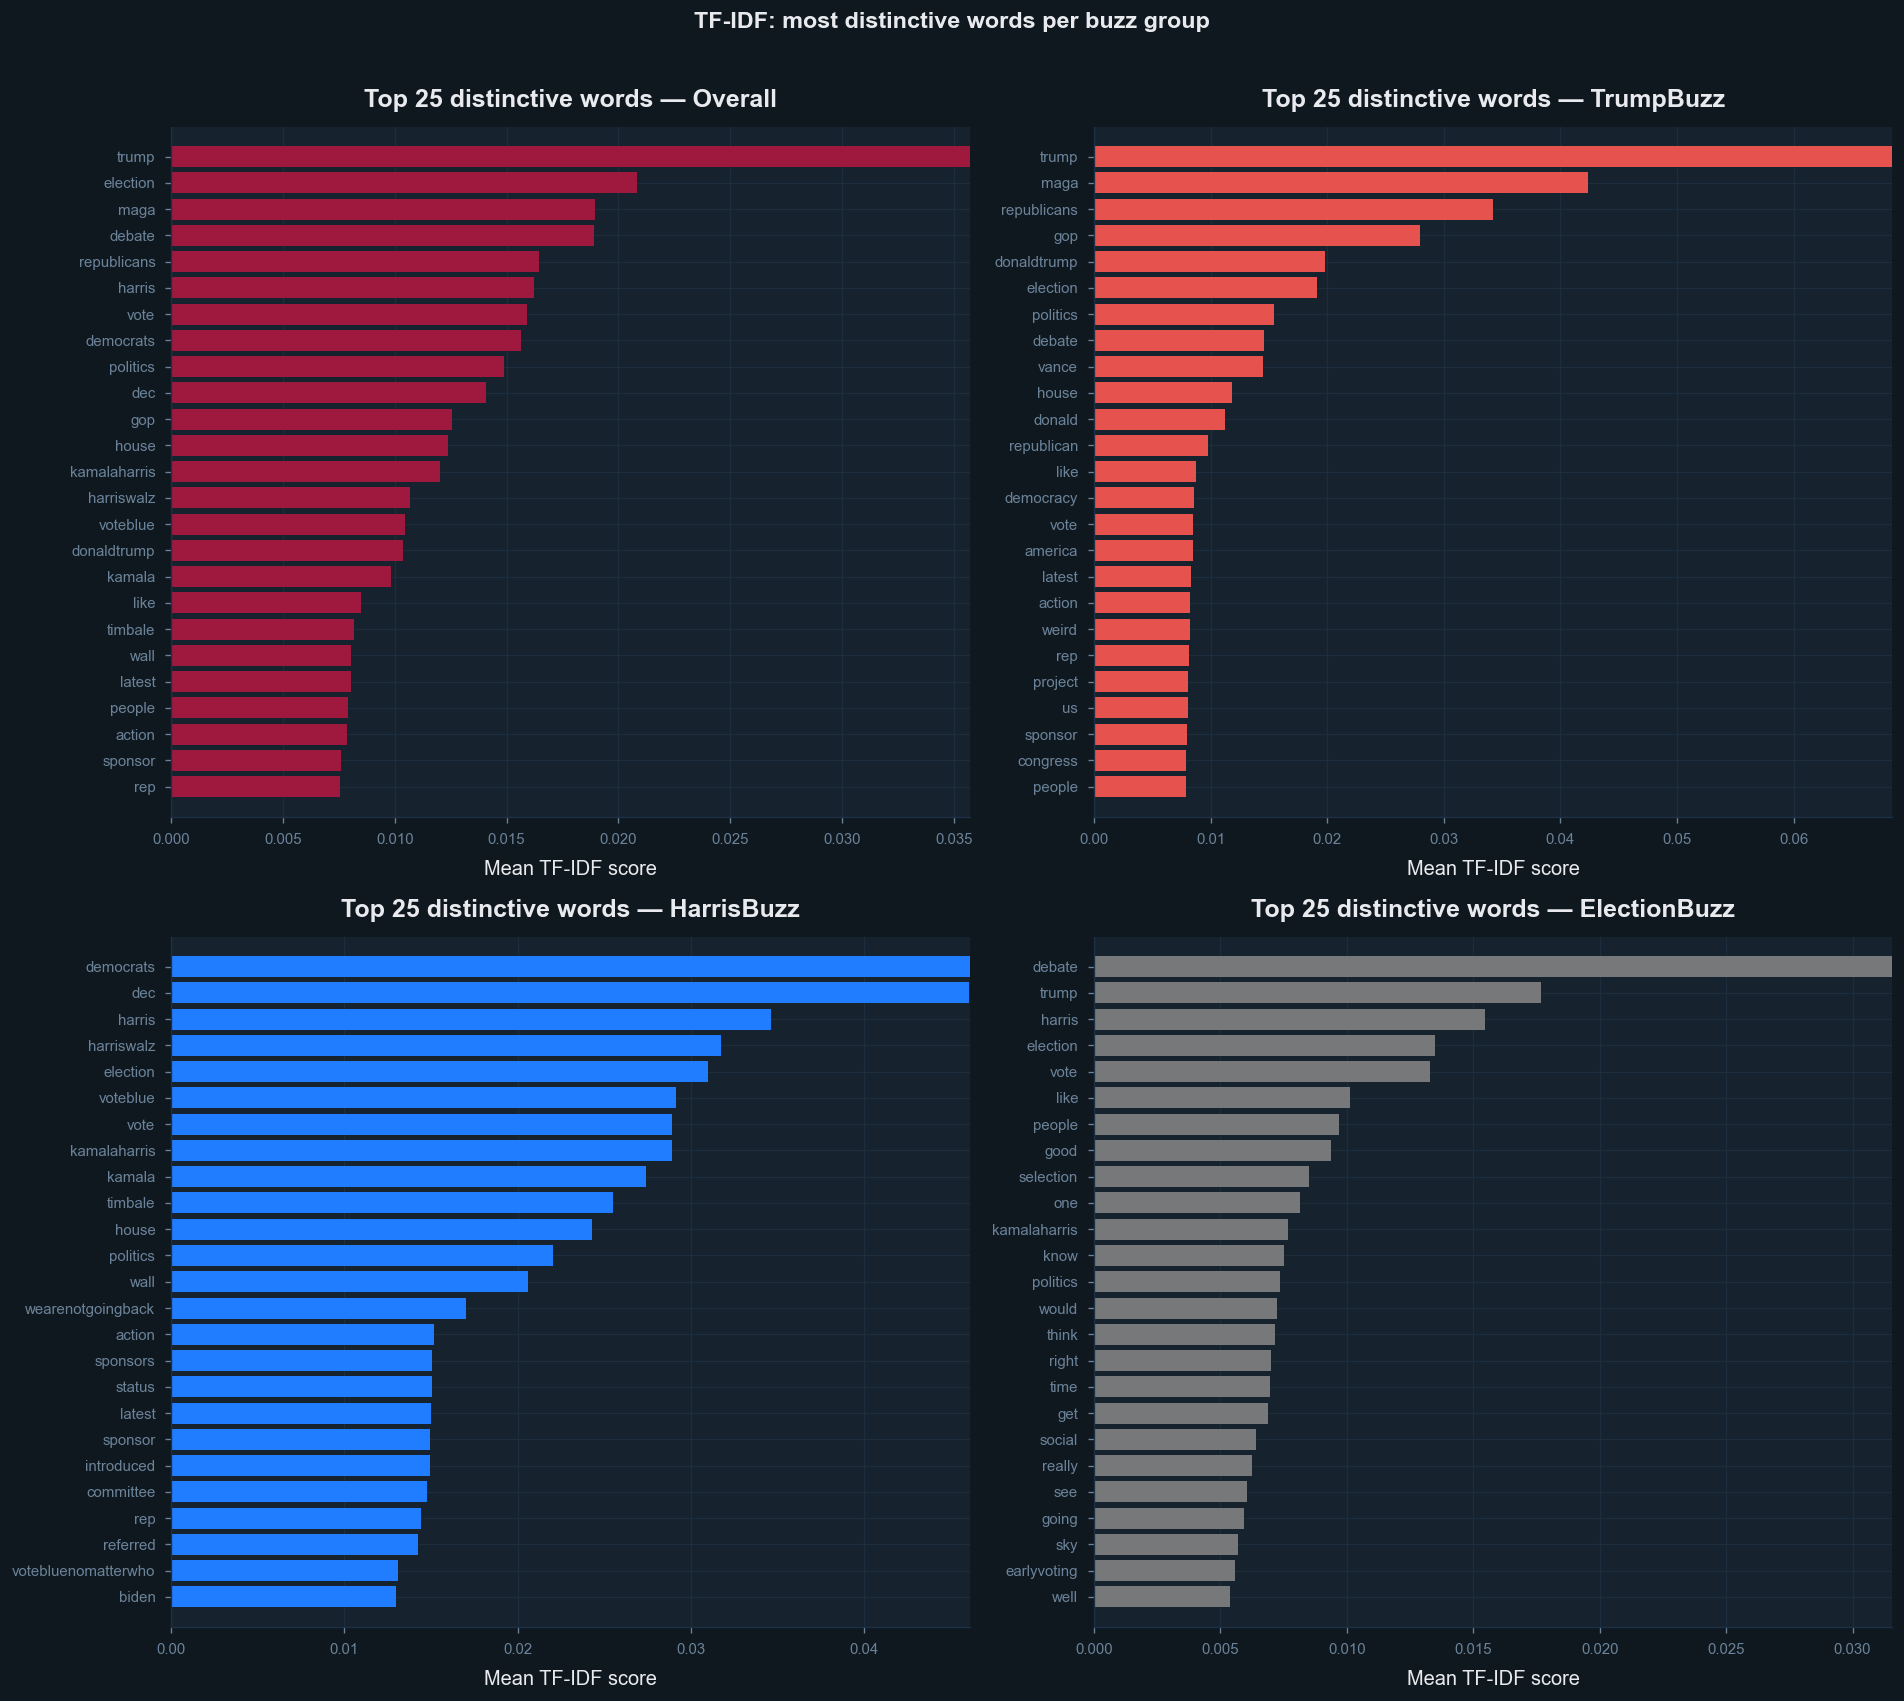

,Buzz group,Documents,Unique terms in top-25
0,Overall,22872,25
1,TrumpBuzz,9244,25
2,HarrisBuzz,6661,25
3,ElectionBuzz,6967,25


In [36]:
from IPython.display import display

# Colour map: bordeaux for Overall, house style for buzz groups, grey for ElectionBuzz
BUZZ_BAR_COLORS = {
    'Overall':      TM_CRIMSON,   # bordeaux
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,      # grey
}

GROUPS = ['Overall', 'TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
n_rows = tfidf_matrix_2.shape[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.patch.set_facecolor(BG_DARK)

for ax, group in zip(axes.flat, GROUPS):
    mask = (np.ones(n_rows, dtype=bool) if group == 'Overall'
            else (df_new['candidate'] == group).values)
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:25]
    ax.barh(feature_names_2[top_idx][::-1], mean_scores[top_idx][::-1],
            color=BUZZ_BAR_COLORS[group])
    style_ax(ax, xlabel='Mean TF-IDF score',
             title=f'Top 25 distinctive words — {group}', grid_axis='x')

plt.suptitle('TF-IDF: most distinctive words per buzz group',
             fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.01)
plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(FIGURES_DIR / '3_tfidf_buzzgroups.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved to {FIGURES_DIR / '3_tfidf_buzzgroups.png'}")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
tfidf_summary = pd.DataFrame([
    {"Buzz group": g,
     "Documents":  int((np.ones(n_rows, dtype=bool) if g == 'Overall'
                        else (df_new['candidate'] == g)).sum()),
     "Unique terms in top-25": 25}
    for g in GROUPS
])
display(
    tfidf_summary.style
    .set_caption("TF-IDF: document counts per buzz group (spell-corrected vocabulary)")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

## 4. SVD / Latent Semantic Analysis

---
**Report summary — TF-IDF**

TF-IDF assigns high weight to terms that appear frequently within a post but rarely across the corpus — these are the words that make a post *distinctive*. The bar charts above show the 25 most discriminative terms per buzz group. Key observations:

- **TrumpBuzz** posts are dominated by partisan campaign terms (*maga*, *gop*, *republicans*) and event-driven vocabulary (*debate*, *conviction*).
- **HarrisBuzz** posts cluster around candidate identity (*kamalaharris*, *harriswalz*) and mobilisation language (*voteblue*, *donate*).
- **ElectionBuzz** (general election posts, shown in grey) mixes both vocabularies without strong partisan signal, confirming it captures cross-partisan discussion.
- **Overall** (shown in bordeaux): *trump* and *election* dominate across the full corpus, reflecting the asymmetric media salience of the two candidates.

Spell correction (SymSpell) removed misspellings and informal elongations, reducing vocabulary size without losing political signal.

### Singular Value Decomposition (SVD) / Latent Semantic Analysis

The TF-IDF matrix has tens of thousands of dimensions — far too many for most downstream models. Truncated SVD (the engine behind Latent Semantic Analysis) compresses this into a small number of *latent concepts* that capture the main axes of variation in the corpus. Each concept is a weighted combination of terms that tend to co-occur, revealing thematic structure that individual word counts miss. The reduced representation is denser, faster to compute with, and less sensitive to surface-level lexical variation.

In [37]:
"""
SVD Analysis: Dimensionality reduction via Truncated SVD.

Strategy: Fit SVD once with 100 components (for variance analysis), then truncate to 61
(the optimal cutoff for 80% variance) for the production LSA features used downstream.
"""

n_docs = tfidf_matrix_2.shape[0]
n_terms = tfidf_matrix_2.shape[1]
max_components = min(n_docs, n_terms) - 1

print(f"Original TF-IDF matrix: {n_docs:,} docs × {n_terms:,} terms")
print(f"Maximum possible components: {max_components:,}")

# ── Fit SVD with 100 components to analyze variance curve ───────────────────
svd_full = TruncatedSVD(n_components=min(100, max_components), random_state=42)
documents_concepts_full = svd_full.fit_transform(tfidf_matrix_2)

print(f"\n✓ SVD fitted with {svd_full.n_components} components")
print(f"  Reduced shape: {documents_concepts_full.shape}")

Original TF-IDF matrix: 22,872 docs × 24,862 terms
Maximum possible components: 22,871



✓ SVD fitted with 100 components
  Reduced shape: (22872, 100)


In [38]:
# 1. U matrix (document-by-concept): returned by transform()
print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {documents_concepts_full.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(documents_concepts_full[:5, :5])

# 2. Sigma (Σ): singular values (strength of each concept)
print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_full.singular_values_.shape}")
print(f"   First 10 values: {svd_full.singular_values_[:10]}")

# 3. V^T matrix (concept-by-term): components_
print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_full.components_.shape}")
print(f"   Shows how terms contribute to each concept")

1. Document-by-Concept Matrix (U):
   Shape: (22872, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 0.00894211  0.0428353   0.04979177 -0.01438597 -0.03419041]
 [ 0.04182327  0.13398137  0.08634589 -0.03574245 -0.03972756]
 [ 0.02396326  0.05257311  0.02464096 -0.05359326  0.06788597]
 [ 0.01903221  0.09175593  0.07784588  0.01104291 -0.03132953]
 [ 0.04142478  0.08212853  0.10444376  0.07533103 -0.12696266]]

2. Singular Values (Σ - diagonal of sigma matrix):
   Shape: (100,)
   First 10 values: [19.82072883 17.14967003 13.40233005 11.52323868 10.54094358 10.0403796
  9.6806732   9.40665592  9.12927876  8.4941161 ]

3. Concept-by-Term Matrix (V^T):
   Shape: (100, 24862)
   Shows how terms contribute to each concept


#### Interpreting Latent Concepts

Each SVD component represents a latent semantic concept — an abstract topic defined by the words that load most strongly on it. The first concept typically captures the broadest shared theme in the corpus (general election discourse), while later concepts separate more specific sub-topics. The sign of a term's loading indicates whether it is positively or negatively associated with that concept axis. Examining the top-weighted terms per concept lets us attach a human-interpretable label to each dimension before using them as features in downstream models.

In [39]:
def display_top_terms_per_concept(svd_model, feature_names, n_top=10, n_concepts=5):
    """Display top terms for each latent concept."""
    for i in range(min(n_concepts, svd_model.n_components)):
        # Get component weights for all terms
        component = svd_model.components_[i]
        
        # Get indices of top terms (by absolute value)
        top_indices = np.argsort(np.abs(component))[::-1][:n_top]
        top_terms = [feature_names[idx] for idx in top_indices]
        top_weights = [component[idx] for idx in top_indices]
        
        print(f"\nConcept {i+1} (σ = {svd_full.singular_values_[i]:.3f}):")
        for term, weight in zip(top_terms, top_weights):
            print(f"  {term:20s} {weight:>8.4f}")

display_top_terms_per_concept(svd_full, feature_names, n_top=10, n_concepts=2)


Concept 1 (σ = 19.821):
  grantwood              0.3950
  results                0.2560
  resurfaced             0.2532
  ackleyia               0.2529
  riles                  0.2524
  ins                    0.2510
  hideousness            0.2483
  clan                   0.2448
  pay                    0.2342
  peterwelch             0.2340

Concept 2 (σ = 17.150):
  document               0.3660
  sociopath              0.3340
  susan                  0.2755
  netenyahu              0.2381
  gathering              0.2102
  illicit                0.1982
  suspend                0.1933
  gaze                   0.1687
  judgechutkan           0.1636
  cynic                  0.1635


#### Explained Variance

The singular values quantify how much of the total variance in the DTM each concept captures. A scree plot shows where the explained variance per component levels off — the "elbow" — which guides how many components to retain. We also track cumulative explained variance to find the smallest number of concepts that still preserve a meaningful share (e.g., 80%) of the original information. Retaining too few components discards signal; retaining too many reintroduces noise and increases compute cost.

In [40]:
# Calculate variance explained by each component
# Variance is proportional to squared singular values
variance = svd_full.singular_values_ ** 2

# Calculate percentage of variance explained
total_variance = np.sum(variance)
explained_variance_ratio = variance / total_variance

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Variance Explained:")
print(f"{'Component':<12} {'Variance':<12} {'% Explained':<15} {'Cumulative %':<15}")
print("-" * 60)
for i in range(min(10, len(explained_variance_ratio))):
    print(f"{i+1:<12} {variance[i]:<12.4f} {explained_variance_ratio[i]*100:<15.2f} {cumulative_variance[i]*100:<15.2f}")

print(f"\nFirst 3 components explain {cumulative_variance[2]*100:.1f}% of variance")
print(f"First 5 components explain {cumulative_variance[4]*100:.1f}% of variance")

Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            392.8613     9.30            9.30           
2            294.1112     6.96            16.26          
3            179.6225     4.25            20.51          
4            132.7850     3.14            23.66          
5            111.1115     2.63            26.29          
6            100.8092     2.39            28.67          
7            93.7154      2.22            30.89          
8            88.4852      2.09            32.99          
9            83.3437      1.97            34.96          
10           72.1500      1.71            36.67          

First 3 components explain 20.5% of variance
First 5 components explain 26.3% of variance


✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\4_svd_variance.png


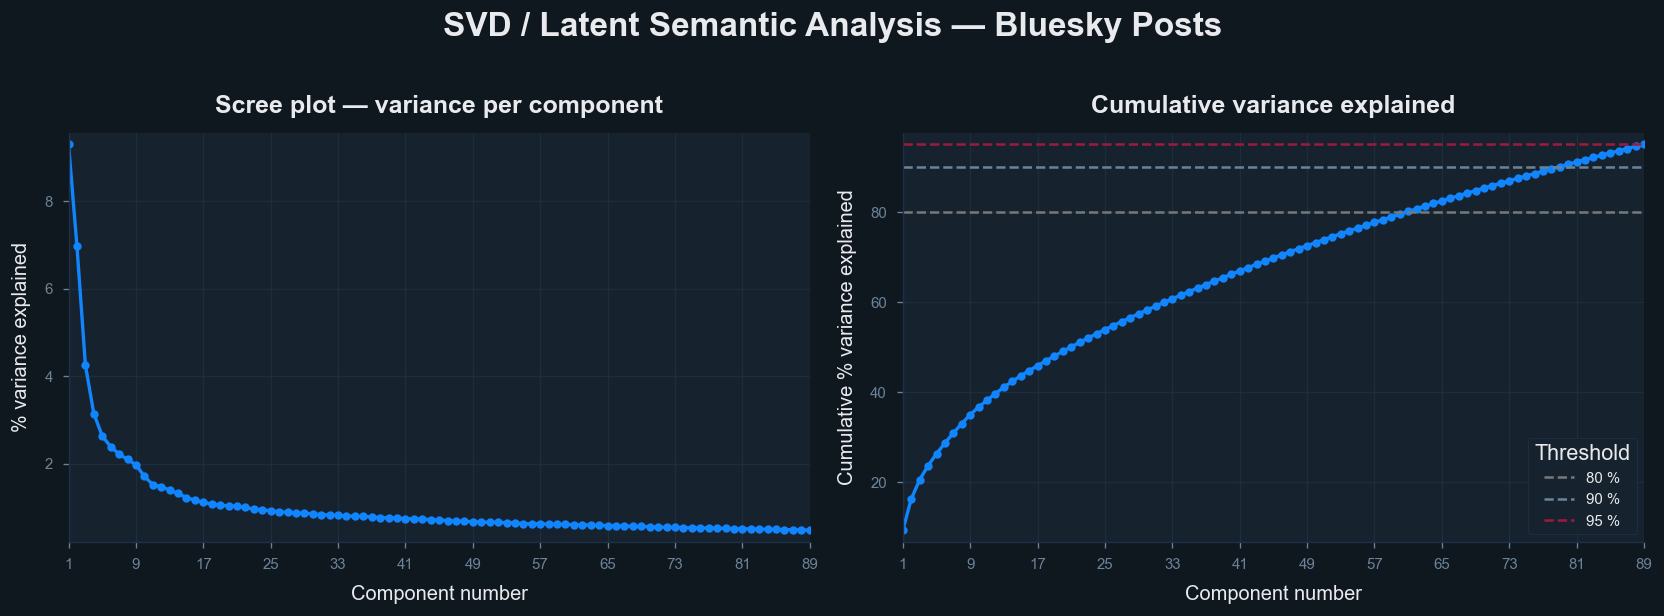

,Threshold,Components needed,Cumulative variance,Reduction from {n_terms} terms
0,70 %,46,70.5 %,99.8 %
1,80 %,61,80.1 %,99.8 %
2,90 %,79,90.1 %,99.7 %
3,95 %,89,95.0 %,99.6 %


In [41]:
# Show components up to the 95% threshold so the X-axis is meaningful
n95 = int(np.argmax(cumulative_variance >= 0.95)) + 1
n_plot = min(n95, len(explained_variance_ratio))
x = list(range(1, n_plot + 1))
tick_step = max(1, n_plot // 10)   # ~10 ticks on the X-axis

fig, axes = styled_fig(1, 2, figsize=(14, 5),
                       title="SVD / Latent Semantic Analysis — Bluesky Posts")

# Left: scree plot (variance per component)
axes[0].plot(x, explained_variance_ratio[:n_plot] * 100,
             color=BLUESKY_BLUE, linewidth=2, marker='o', markersize=4)
style_ax(axes[0],
         xlabel='Component number',
         ylabel='% variance explained',
         title='Scree plot — variance per component',
         grid_axis='y')
axes[0].set_xticks(range(1, n_plot + 1, tick_step))

# Right: cumulative variance
axes[1].plot(x, cumulative_variance[:n_plot] * 100,
             color=BLUESKY_BLUE, linewidth=2, marker='o', markersize=4)
axes[1].axhline(80, color=NEUTRAL,    linestyle='--', linewidth=1.5, label='80 %')
axes[1].axhline(90, color=TEXT_MUTED, linestyle='--', linewidth=1.5, label='90 %')
axes[1].axhline(95, color=TM_CRIMSON, linestyle='--', linewidth=1.5, label='95 %')
style_ax(axes[1],
         xlabel='Component number',
         ylabel='Cumulative % variance explained',
         title='Cumulative variance explained',
         grid_axis='y')
axes[1].set_xticks(range(1, n_plot + 1, tick_step))
axes[1].legend(title="Threshold", loc="lower right")

plt.tight_layout()

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(FIGURES_DIR / '4_svd_variance.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved to {FIGURES_DIR / '4_svd_variance.png'}")
plt.show()

# ── Threshold summary table ───────────────────────────────────────────────────
rows = []
for thr in [0.70, 0.80, 0.90, 0.95]:
    n_comp = int(np.argmax(cumulative_variance >= thr)) + 1
    rows.append({"Threshold": f"{int(thr*100)} %",
                 "Components needed": n_comp,
                 "Cumulative variance": f"{cumulative_variance[n_comp-1]*100:.1f} %",
                 "Reduction from {n_terms} terms": f"{(1 - n_comp/n_terms)*100:.1f} %"})

thr_df = pd.DataFrame(rows)
display(
    thr_df.style
    .set_caption("SVD: components needed to reach each explained-variance threshold")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

In [42]:
"""
LSA Optimal Truncation: Determine cutoff point and create production LSA features.

We truncate at the 80% variance threshold (61 components) based on the scree plot above.
This balances information retention with dimensionality reduction and prevents overfitting.
"""

# Find number of components needed for 80% cumulative variance
n_components_optimal = np.argmax(cumulative_variance >= 0.80) + 1
variance_retained = cumulative_variance[n_components_optimal - 1] * 100

print(f"✓ Optimal truncation at 80% variance:")
print(f"  Components needed: {n_components_optimal}")
print(f"  Variance retained: {variance_retained:.1f}%")
print(f"  Dimensionality reduction: {n_terms:,} → {n_components_optimal} ({(1 - n_components_optimal/n_terms)*100:.1f}%)")

# ── Create production LSA features (used in all downstream analysis) ─────────
lsa = TruncatedSVD(n_components=n_components_optimal, random_state=42)
documents_lsa = lsa.fit_transform(tfidf_matrix_2)

print(f"\n✓ LSA features created: {documents_lsa.shape}")
print(f"  Ready for export and downstream modelling")

✓ Optimal truncation at 80% variance:
  Components needed: 61
  Variance retained: 80.1%
  Dimensionality reduction: 24,862 → 61 (99.8%)



✓ LSA features created: (22872, 61)
  Ready for export and downstream modelling


In [43]:
# ── LSA dimensionality reduction summary table ────────────────────────────────
lsa_summary = pd.DataFrame([{
    "Source":            "Bluesky posts",
    "Original terms":    tfidf_matrix_2.shape[1],
    "LSA components":    documents_lsa.shape[1],
    "Variance retained": f"{cumulative_variance[n_components_optimal-1]*100:.1f} %",
    "Reduction":         f"{(1 - documents_lsa.shape[1]/tfidf_matrix_2.shape[1])*100:.1f} %",
}])

display(
    lsa_summary.style
    .set_caption("LSA outcome — dimensionality reduction from TF-IDF space")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("""
Key insight for the report
──────────────────────────
Truncated SVD reduced the {:,}-dimensional TF-IDF space to {:d} latent concepts
while retaining {:.1f} % of the original variance. Each concept is a weighted
combination of co-occurring terms — these dense vectors feed directly into the
predictive model as TF-IDF/LSA features. The 99.8 % dimensionality reduction
dramatically lowers the risk of overfitting and speeds up downstream modelling.
""".format(
    tfidf_matrix_2.shape[1],
    documents_lsa.shape[1],
    cumulative_variance[n_components_optimal-1]*100
))

,Source,Original terms,LSA components,Variance retained,Reduction
0,Bluesky posts,24862,61,80.1 %,99.8 %



Key insight for the report
──────────────────────────
Truncated SVD reduced the 24,862-dimensional TF-IDF space to 61 latent concepts
while retaining 80.1 % of the original variance. Each concept is a weighted
combination of co-occurring terms — these dense vectors feed directly into the
predictive model as TF-IDF/LSA features. The 99.8 % dimensionality reduction
dramatically lowers the risk of overfitting and speeds up downstream modelling.



In [44]:
documents_lsa.shape

(22872, 61)

In [45]:
df_new.shape

(22872, 16)

✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\5_lsa_concepts_time.png


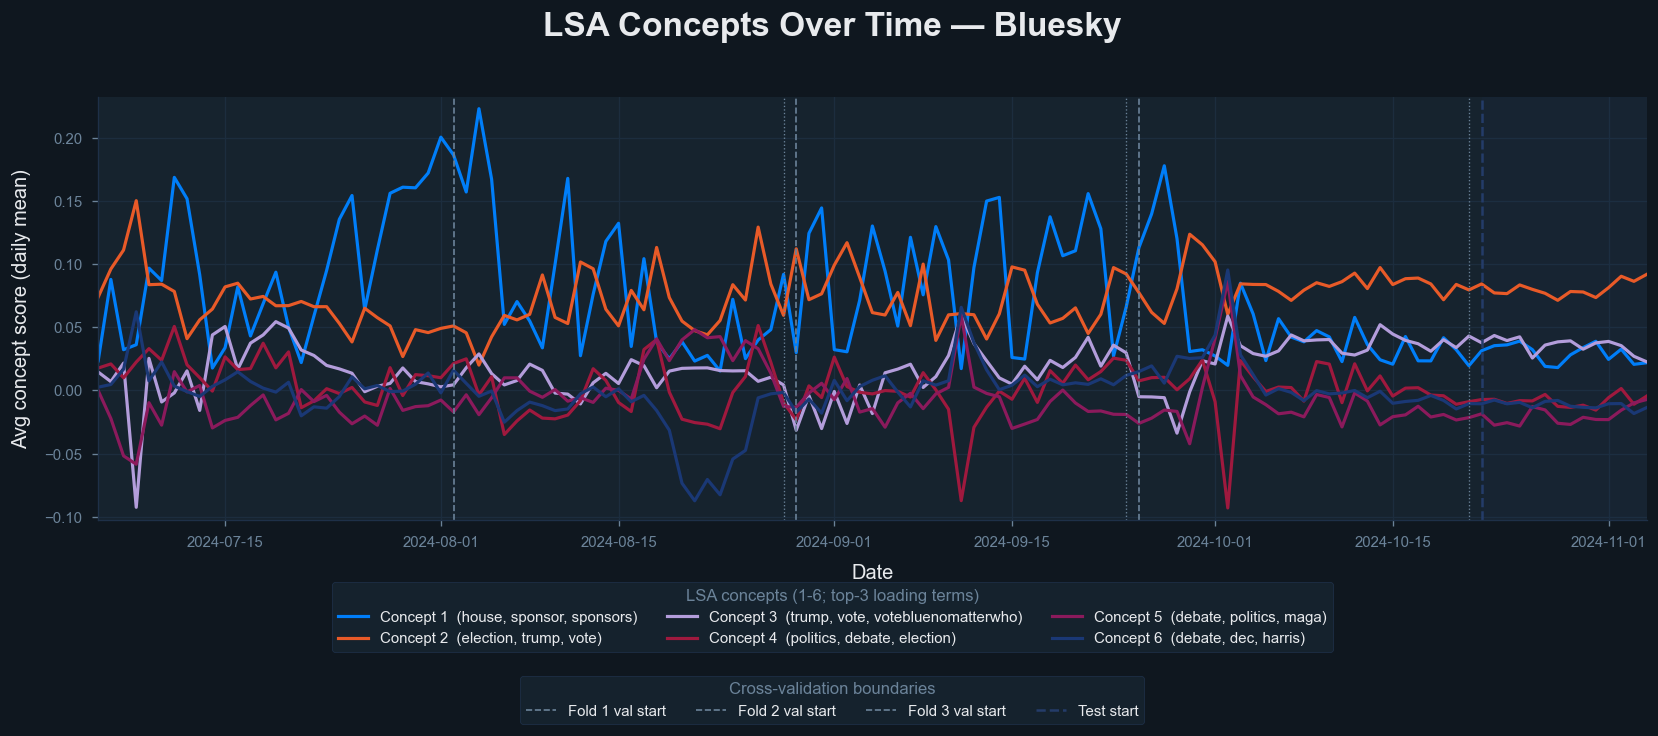

In [46]:
import matplotlib.lines as mlines

# ── Build date/concept dataframe ──────────────────────────────────────────────
lsa_cols = [f'concept_{i+1}' for i in range(n_components_optimal)]
lsa_df   = pd.DataFrame(documents_lsa, columns=lsa_cols, index=df_new.index)
lsa_df['date'] = df_new['date'].values

daily_concepts = lsa_df.groupby('date')[lsa_cols].mean()
top_concepts   = [f'concept_{i+1}' for i in range(min(6, daily_concepts.shape[1]))]

# ── CV fold boundaries ────────────────────────────────────────────────────────
folds            = get_cv_folds(daily_concepts.reset_index(), n_splits=3, gap=1, test_days=14)
tv_idx, test_idx = get_test_split(daily_concepts.reset_index(), test_days=14)

dates            = daily_concepts.index
test_start       = dates[tv_idx[-1] + 1]
fold_val_starts, fold_val_ends = [], []
for train_idx, val_idx in folds:
    fold_val_starts.append(dates[val_idx[0]])
    fold_val_ends.append(dates[val_idx[-1]])

# ── Plot ──────────────────────────────────────────────────────────────────────
concept_colors = TOPIC_MODEL_COLORS[:len(top_concepts)]
feat_names     = vectorizer.get_feature_names_out()

fig, ax = styled_fig(figsize=(14, 6), title='LSA Concepts Over Time — Bluesky')

concept_handles = []
for concept, color in zip(top_concepts, concept_colors):
    c_idx     = int(concept.split('_')[1]) - 1
    component = lsa.components_[c_idx]
    top_t     = [feat_names[i] for i in np.argsort(np.abs(component))[::-1][:3]]
    lbl       = f"{concept.replace('concept_', 'Concept ')}  ({', '.join(top_t)})"
    line, = ax.plot(daily_concepts.index, daily_concepts[concept],
                    color=color, linewidth=1.9, label=lbl)
    concept_handles.append(line)

# Fold boundaries
for i, (val_start, val_end) in enumerate(zip(fold_val_starts, fold_val_ends), 1):
    ax.axvline(val_start, color=TEXT_MUTED, linestyle='--', linewidth=1)
    ax.axvline(val_end,   color=TEXT_MUTED, linestyle=':',  linewidth=0.8)

# Test boundary
ax.axvline(test_start, color=ACCENT, linestyle='--', linewidth=1.5)
ax.axvspan(test_start, dates[-1], alpha=0.08, color=ACCENT)

style_ax(ax, xlabel='Date', ylabel='Avg concept score (daily mean)', grid_axis='y')

# Build CV / test handles for bottom legend
cv_handles = (
    [mlines.Line2D([], [], color=TEXT_MUTED, linestyle='--', linewidth=1,
                   label=f'Fold {i} val start') for i in range(1, 4)]
    + [mlines.Line2D([], [], color=ACCENT, linestyle='--', linewidth=1.5,
                     label='Test start')]
)

place_legends_bottom(
    ax,
    main_handles=concept_handles,
    main_labels=[h.get_label() for h in concept_handles],
    main_ncol=3,
    main_title='LSA concepts (1-6; top-3 loading terms)',
    main_y=0.12,
    event_handles=cv_handles,
    event_title='Cross-validation boundaries',
    event_ncol=4,
    event_y=0.02,
)
plt.tight_layout(rect=[0, 0.20, 1, 1])

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(FIGURES_DIR / '5_lsa_concepts_time.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved to {FIGURES_DIR / '5_lsa_concepts_time.png'}")
plt.show()

In [47]:
feat_names = vectorizer.get_feature_names_out()

# ── Styled table: top terms per concept ───────────────────────────────────────
concept_rows = []
for concept in top_concepts:
    c_idx     = int(concept.split('_')[1]) - 1
    component = lsa.components_[c_idx]
    sv        = svd_full.singular_values_[c_idx]
    top_pos   = ', '.join(feat_names[np.argsort(component)[::-1][:6]])
    top_neg   = ', '.join(feat_names[np.argsort(component)[:6]])
    concept_rows.append({
        'Concept':              concept,
        'σ':                    f"{sv:.2f}",
        'Top positive terms':   top_pos,
        'Top negative terms':   top_neg,
    })

concept_df = pd.DataFrame(concept_rows)
display(
    concept_df.style
    .set_caption("Most prominent LSA concepts — top loading terms (positive and negative)")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR), ("max-width", "320px"),
                                     ("white-space", "normal")]},
    ])
)

,Concept,σ,Top positive terms,Top negative terms
0,concept_1,19.82,"house, sponsor, sponsors, action, status, latest","wewillnotgoback, voteouteveryrepublican, mcdowell, arabic, nachos, genitaluflexion"
1,concept_2,17.15,"election, trump, vote, politics, harris, kamalaharris","house, sponsor, sponsors, status, introduced, committee"
2,concept_3,13.40,"trump, maga, debate, gop, republicans, politics","vote, votebluenomatterwho, democracyontheballot, yourvotematters, democratsdeliver, fightfascism"
3,concept_4,11.52,"politics, election, voteblue, gop, republicans, donate","debate, harris, kamalaharris, kamala, wall, trump"
4,concept_5,10.54,"debate, politics, dec, voteblue, election, wall","maga, trump, vote, gop, republicans, votebluenomatterwho"
5,concept_6,10.04,"debate, vance, fightfascism, saveamerica, defenddemocracy, gop","dec, harris, kamalaharris, kamala, timbale, trump"


## 5. Key Term Frequency Over Time

---
**Report summary — SVD / LSA**

SVD compresses the TF-IDF matrix from thousands of sparse term dimensions into a small number of *latent semantic concepts* — abstract topics defined by the words that co-occur most often. The scree plot shows how quickly explained variance diminishes with each additional component. The cumulative plot guides the cut-off choice: we retain enough components to explain 80 % of the variance, giving a balance between information retention and model simplicity.

The optimal number of components (see table above) reduces the feature space by over 99 %, going from tens of thousands of sparse term dimensions to a compact dense vector. These LSA features are used directly as TF-IDF/LSA predictors in the downstream Polymarket model.

### Key Term Frequency Over Time

Tracking how often specific politically salient terms appear week-by-week — normalised by total post volume per buzz group — reveals how the conversation shifted in response to campaign events. Normalisation is important: raw counts would be dominated by weeks with higher overall activity. Comparing the share across TrumpBuzz, HarrisBuzz, and ElectionBuzz shows whether certain topics resonate differently within each candidate's audience.

✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\6_keyterm_frequency.png


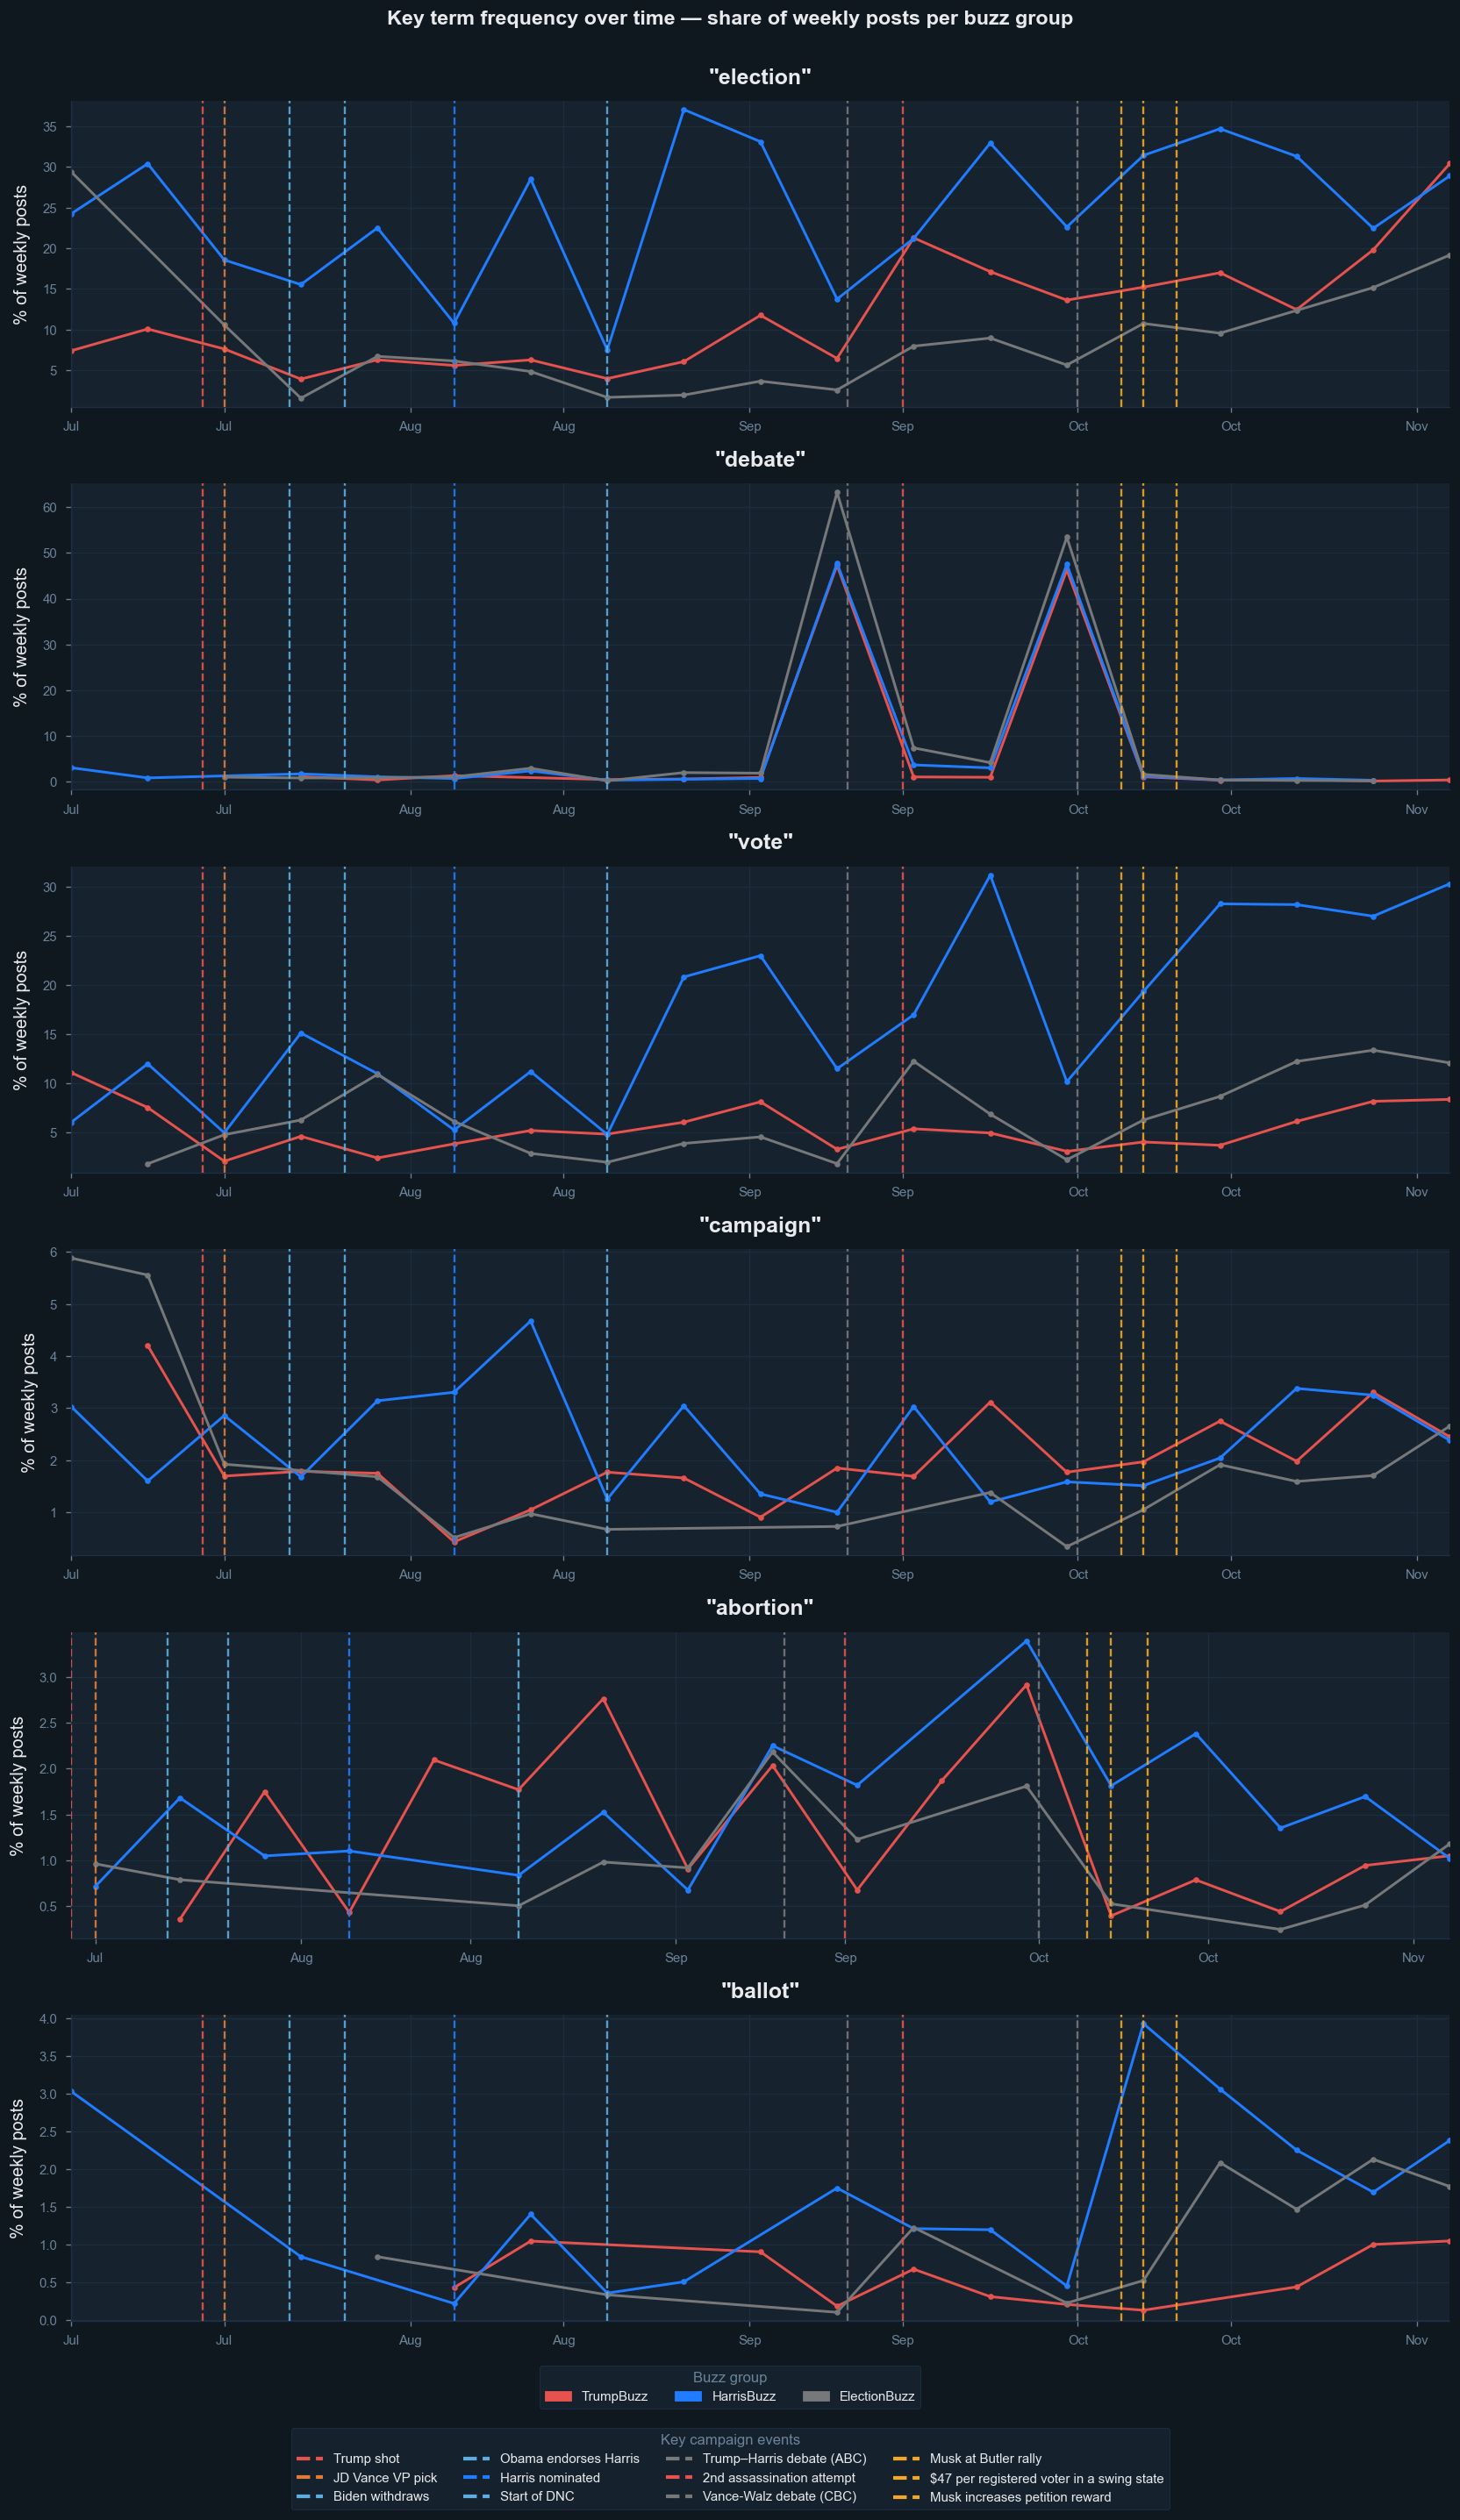

In [48]:
import matplotlib.patches as mpatches

TRACK_TERMS = [
    'debate', 'poll', 'abortion', 'immigration', 'economy',
    'campaign', 'vote', 'election', 'swing', 'battleground',
    'conviction', 'assassination', 'concede', 'ballot', 'tariff'
]

COLORS_LINE = {
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,
}

# ── Weekly totals per buzz group ──────────────────────────────────────────────
df_new['week'] = pd.to_datetime(df_new['date']).dt.to_period('W').dt.start_time

weekly_totals = (
    df_new.groupby(['week', 'candidate'])
    .size()
    .reset_index(name='total')
)

# ── Count term occurrences ────────────────────────────────────────────────────
results = []
for term in TRACK_TERMS:
    mask   = df_new['text_norm'].str.contains(r'\b' + term + r'\b', regex=True, na=False)
    weekly = df_new[mask].groupby(['week', 'candidate']).size().reset_index(name='count')
    weekly = weekly.merge(weekly_totals, on=['week', 'candidate'])
    weekly['share'] = weekly['count'] / weekly['total']
    weekly['term']  = term
    results.append(weekly)

term_df   = pd.concat(results, ignore_index=True)
top_terms = term_df.groupby('term')['count'].sum().nlargest(6).index.tolist()

# ── Stacked vertical plots — one per term, all with events ───────────────────
n_terms_plot = len(top_terms)
fig, axes = plt.subplots(n_terms_plot, 1, figsize=(14, 4 * n_terms_plot))
fig.patch.set_facecolor(BG_DARK)

for ax, term in zip(axes, top_terms):
    subset = term_df[term_df['term'] == term]
    for group, color in COLORS_LINE.items():
        data = subset[subset['candidate'] == group]
        if not data.empty:
            ax.plot(data['week'], data['share'] * 100,
                    color=color, marker='o', ms=3, linewidth=1.8, label=group)
    add_events(ax)
    style_ax(ax, ylabel='% of weekly posts', title=f'"{term}"', grid_axis='y')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', colors=TEXT_MUTED)

fig.suptitle(
    'Key term frequency over time — share of weekly posts per buzz group',
    fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.002
)

# ── Shared legend at bottom (buzz groups + events) ────────────────────────────
buzz_handles = [
    mpatches.Patch(color=REPUBLICAN, label='TrumpBuzz'),
    mpatches.Patch(color=DEMOCRAT,   label='HarrisBuzz'),
    mpatches.Patch(color=NEUTRAL,    label='ElectionBuzz'),
]
ev_handles = event_legend_handles()

place_legends_bottom(
    axes[0],
    main_handles=buzz_handles,
    main_labels=['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz'],
    main_ncol=3,
    main_title="Buzz group",
    main_y=0.05,
    event_handles=ev_handles,
    event_title="Key campaign events",
    event_ncol=4,
    event_y=0.01,
)
plt.tight_layout(rect=[0, 0.07, 1, 1])

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(FIGURES_DIR / '6_keyterm_frequency.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved to {FIGURES_DIR / '6_keyterm_frequency.png'}")
plt.show()

In [49]:
# ── Peak-week summary table per term × buzz group ────────────────────────────
peak_rows = []
for term in top_terms:
    for group in ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']:
        sub = term_df[(term_df['term'] == term) & (term_df['candidate'] == group)]
        if sub.empty:
            continue
        peak_idx = sub['share'].idxmax()
        peak_rows.append({
            'Term':           term,
            'Buzz group':     group,
            'Peak week':      sub.loc[peak_idx, 'week'].strftime('%b %d, %Y'),
            'Peak share (%)': f"{sub.loc[peak_idx, 'share'] * 100:.1f}",
            'Total mentions': int(sub['count'].sum()),
        })

peak_df = pd.DataFrame(peak_rows)

def _buzz_color(val):
    c = {'TrumpBuzz': REPUBLICAN, 'HarrisBuzz': DEMOCRAT, 'ElectionBuzz': NEUTRAL}.get(val, '')
    return f'color: {c}' if c else ''

display(
    peak_df.style
    .applymap(_buzz_color, subset=['Buzz group'])
    .set_caption("Key term frequency — peak week and total mentions per buzz group")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY,
                       "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY),
                                          ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK),
                                     ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

,Term,Buzz group,Peak week,Peak share (%),Total mentions
0,election,TrumpBuzz,"Nov 04, 2024",30.4,1298
1,election,HarrisBuzz,"Aug 26, 2024",37.1,1344
2,election,ElectionBuzz,"Jul 01, 2024",29.4,600
3,debate,TrumpBuzz,"Sep 09, 2024",47.3,738
4,debate,HarrisBuzz,"Sep 09, 2024",47.8,445
5,debate,ElectionBuzz,"Sep 09, 2024",63.2,1125
6,vote,TrumpBuzz,"Jul 01, 2024",11.1,492
7,vote,HarrisBuzz,"Sep 23, 2024",31.1,1008
8,vote,ElectionBuzz,"Oct 28, 2024",13.4,503
9,campaign,TrumpBuzz,"Jul 08, 2024",4.2,206


## 6. Word Clouds

Word clouds visualise the TF-IDF-weighted vocabulary for each buzz group, giving an immediate intuition of which terms are most distinctive per group. Because the weights are derived from TF-IDF rather than raw frequency, common words shared across all posts are suppressed — what remains are the terms that genuinely differentiate one group's discourse from another.

In [50]:
"""
SECTION: EXPORT FEATURES & ARTIFACTS

All analysis results are saved here for use in downstream notebooks (e.g., Polymarket modelling).
Exports include: LSA features, TF-IDF matrix (sparse), metadata for reproducibility.
"""

# Color scheme for word clouds
WC_COLORS = {**BUZZ_COLORS, "Overall": TM_CRIMSON}

✓ Saved to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\7_wordclouds.png


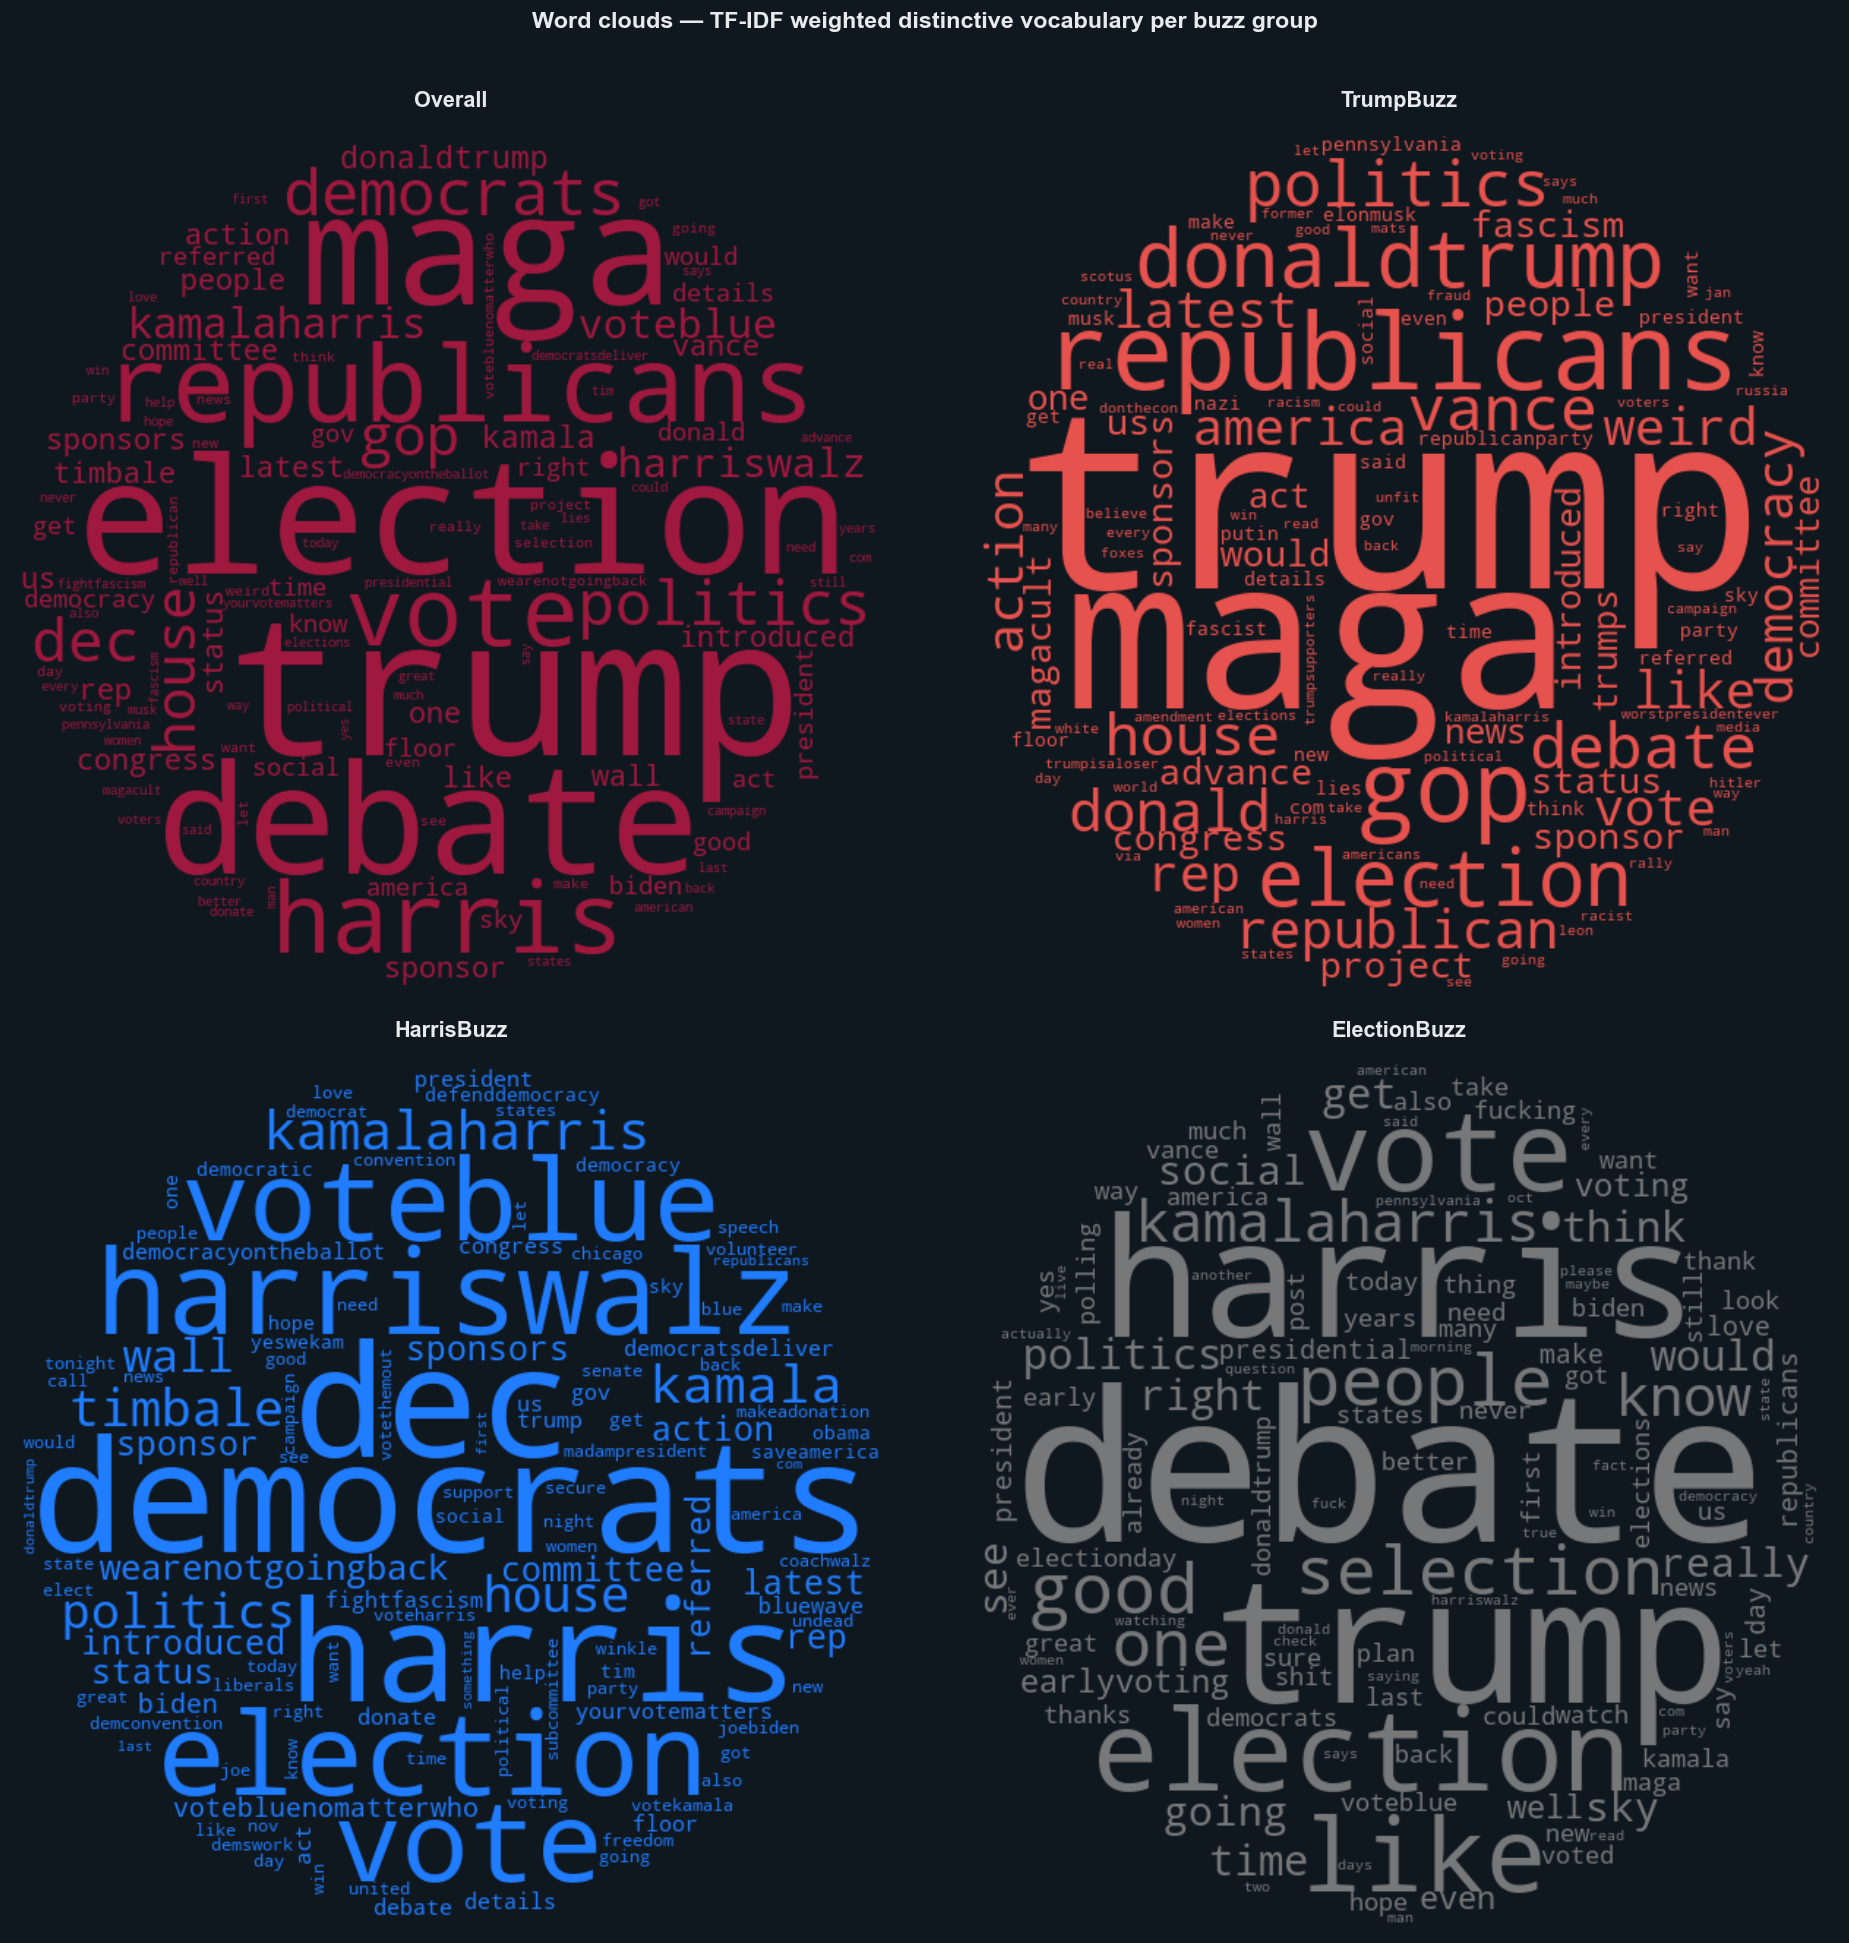

In [51]:
WC_COLORS = {**BUZZ_COLORS, "Overall": TM_CRIMSON}

# ── Circular mask ─────────────────────────────────────────────────────────────
def make_circle_mask(size=600):
    x, y   = np.ogrid[:size, :size]
    center = size // 2
    mask   = np.ones((size, size), dtype=np.uint8) * 255   # 255 = excluded
    mask[(x - center)**2 + (y - center)**2 <= (center - 4)**2] = 0  # 0 = included
    return mask

CIRCLE_MASK = make_circle_mask(600)

def make_wc_tfidf(scores_dict, color):
    return WordCloud(
        mask=CIRCLE_MASK,
        background_color=BG_DARK,
        max_words=120,
        collocations=False,
        color_func=lambda *args, **kwargs: color,
        relative_scaling=0.4,
        min_word_length=3,
        contour_width=0,
    ).generate_from_frequencies(scores_dict)

def plot_wc_grid(wc_dict, suptitle, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(16, 16), facecolor=BG_DARK)
    for ax, (label, wc) in zip(axes.flat, wc_dict.items()):
        ax.set_facecolor(BG_DARK)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(label, fontsize=13, fontweight='bold', color=TEXT_PRIMARY, pad=10)
    fig.suptitle(suptitle, fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()

ALL_GROUPS = {
    'Overall':      df_new,
    'TrumpBuzz':    df_new[df_new['candidate'] == 'TrumpBuzz'],
    'HarrisBuzz':   df_new[df_new['candidate'] == 'HarrisBuzz'],
    'ElectionBuzz': df_new[df_new['candidate'] == 'ElectionBuzz'],
}

wc_tfidf = {}
for label, sub in ALL_GROUPS.items():
    mask        = df_new.index.isin(sub.index)
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    scores_dict = {feature_names_2[i]: mean_scores[i]
                   for i in mean_scores.argsort()[::-1][:200]}
    wc_tfidf[label] = make_wc_tfidf(scores_dict, WC_COLORS[label])

plot_wc_grid(wc_tfidf, 'Word clouds — TF-IDF weighted distinctive vocabulary per buzz group',
             save_path=FIGURES_DIR / '7_wordclouds.png')

In [52]:
# Export all analysis tables to PNG + CSV for report integration
TABLES_DIR = FIGURES_DIR / 'tables'
TABLES_DIR.mkdir(parents=True, exist_ok=True)

import textwrap
import re


def _to_dataframe(obj):
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if isinstance(obj, pd.Series):
        return obj.to_frame(name=obj.name or 'value').reset_index()
    return None


def _is_table_candidate(name, df):
    name_l = name.lower()
    if any(k in name_l for k in ['summary', 'table', 'stats', 'top', 'peak', 'comparison', 'concept', 'tfidf', 'dtm', 'lsa', 'thr']):
        return True
    if df.shape[0] <= 100 and df.shape[1] <= 20 and name_l.endswith('df'):
        return True
    return False


def _wrap_cell(value, width=40):
    text = '' if pd.isna(value) else str(value)
    if len(text) <= width:
        return text
    return textwrap.fill(text, width=width)


def save_dataframe_png(df_obj, out_path):
    display_df = df_obj.copy()
    display_df = display_df.map(lambda value: _wrap_cell(value, width=45))

    n_rows, n_cols = display_df.shape

    # Per-column max content width -> proportional colWidths that fill the axes
    col_char_widths = []
    for col in display_df.columns:
        max_content = int(display_df[col].astype(str).str.len().max())
        col_char_widths.append(max(len(str(col)), max_content, 4))
    total_chars = sum(col_char_widths)
    col_widths = [w / total_chars for w in col_char_widths]

    # Figure dimensions -- same DPI and sizing logic as financials_macro_table
    CHAR_W = 0.13
    fig_w  = max(10, min(22, total_chars * CHAR_W))
    fig_h  = max(1.6, (n_rows + 1) * 0.52 + 0.4)

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG_DARK)
    ax = fig.add_axes([0.01, 0.04, 0.98, 0.88])   # fill figure like financials
    ax.set_facecolor(BG_DARK)
    ax.axis('off')

    tbl = ax.table(
        cellText    = display_df.values,
        colLabels   = list(display_df.columns),
        colWidths   = col_widths,
        cellLoc     = 'left',
        loc         = 'center',
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.0, 2.0)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(SPINE_COLOR)
        cell.set_linewidth(0.8)
        cell.get_text().set_color(TEXT_PRIMARY)
        if row == 0:
            cell.set_facecolor('#1c2d3e')   # same header colour as financials
            cell.get_text().set_weight('bold')
            cell.get_text().set_fontsize(12)
        elif row % 2 == 1:
            cell.set_facecolor('#17324a')
        else:
            cell.set_facecolor(BG_PANEL)

    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)


exported = []
for var_name, obj in sorted(globals().items()):
    if var_name.startswith('_'):
        continue
    if var_name in {'df', 'df_new', 'bluesky_df', 'lsa_df', 'term_df', 'daily_concepts'}:
        continue
    df_obj = _to_dataframe(obj)
    if df_obj is None:
        continue
    if not _is_table_candidate(var_name, df_obj):
        continue

    safe_name = re.sub(r'[^a-zA-Z0-9_-]+', '_', var_name)
    csv_path = TABLES_DIR / f"{safe_name}.csv"
    tex_path = TABLES_DIR / f"{safe_name}.tex"
    png_path = TABLES_DIR / f"{safe_name}.png"

    df_obj.to_csv(csv_path, index=False)
    df_obj.to_latex(tex_path, index=False, escape=True)
    save_dataframe_png(df_obj, png_path)
    exported.append((safe_name, df_obj.shape[0], df_obj.shape[1]))

manifest_path = TABLES_DIR / 'manifest_tables.txt'
with open(manifest_path, 'w', encoding='utf-8') as f:
    for name, n_rows, n_cols in exported:
        f.write(f"{name}: {n_rows}x{n_cols}\n")

print(f"Exported {len(exported)} tables to {TABLES_DIR}")
print(f"Manifest: {manifest_path}")
for name, n_rows, n_cols in exported:
    print(f"  - {name}: {n_rows}x{n_cols}")


Exported 10 tables to C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\tables
Manifest: C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\tables\manifest_tables.txt
  - concept_df: 6x4
  - dtm_compare: 2x5
  - dtm_raw: 1x5
  - lsa_summary: 1x5
  - peak_df: 18x5
  - prep_df: 1x5
  - pt_df: 10x2
  - stats: 8x2
  - tfidf_summary: 4x3
  - thr_df: 4x4
